In [91]:
import pandas as pd
import numpy as np
import math
import random
from itertools import combinations
import scipy
from scipy.optimize import curve_fit
from pyepo.model.grb import shortestPathModel
import pyepo
import gurobipy
from torch.utils.data import DataLoader
from torch import nn
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [92]:
def get_path(verts):
    row = 0
    col = 0
    outs = []
    for i in range(8):
        if i in verts:
            outs.append(9*row + col + 4)
            row += 1
        else:
            outs.append(9*row + col)
            col += 1
    z = np.zeros(40, dtype=int)
    z[outs] = 1
    return z

allpaths = np.zeros(shape=(70, 40))
i=0
for comb in combinations(range(8), 4):
    allpaths[i] = get_path(comb)
    i += 1

exploredpaths = np.empty((0, 40))
unexploredpaths = np.empty((0, 40))
unexplorable = [13]

for comb in combinations(range(8), 4):
    path = get_path(comb)
    if np.any([path[i] == 1 for i in unexplorable]):
        unexploredpaths = np.vstack([unexploredpaths, path])
    else:
        exploredpaths = np.vstack([exploredpaths, path])

In [93]:
random.seed(42)
cost = [random.random() for _ in range(40)]

In [94]:
optmodel = shortestPathModel(grid=(5,5))
# optmodel.setObj(cost)
# sol, obj = optmodel.solve()

# print('Obj: {}'.format(obj))
# for i, e in enumerate(optmodel.arcs):
#     if sol[i] > 1e-3:
#         print(e)

In [95]:
num_data = 2000
num_feat = 5
grid=(5,5)
d=40
# x, c = pyepo.data.shortestpath.genData(num_data, num_feat, grid, deg=1, noise_width=0, seed=42)
# x, xtest, c, ctest = train_test_split(x, c, test_size=0.25)
w = np.random.uniform(low=0, high=1, size=(3, d))
a = np.random.normal(loc=np.linspace(2, 6, d), scale=1, size=(d))

In [96]:
def f(x, theta):
    return theta[0] + x[0]*theta[1] + x[1]*theta[2] + x[2]*theta[3]

def getdata(n, a, w):
    theta = np.vstack([a, w])
    noise = np.random.uniform(low=-0.5, high=0.5, size = (n, 1))
    X = np.random.normal(size = (n, 3))
    Y = np.empty((n, d))
    for i in range(n):
        Y[i] = f(X[i], theta) + noise[i]
    return X, Y

X, Y = getdata(num_data, a, w)
X, Xtest, Y, Ytest = train_test_split(X, Y, test_size=0.25)

In [97]:
from torch.utils.data import Dataset

class BanditDataset(Dataset):
    """Dataset that randomly selects paths from a pool of valid paths."""
    
    def __init__(self, x, y, paths, seed=None):
        """
        Args:
            x: input features (num_samples, num_features)
            c: cost vectors (num_samples, num_edges)
            paths: array of valid paths (num_paths, num_edges)
            seed: random seed for reproducibility
        """
        self.x = torch.FloatTensor(x)
        self.y = torch.FloatTensor(y)
        self.paths = torch.FloatTensor(paths)
        zs = np.empty((0, len(paths[0])))
        cs = np.empty((0, 1))

        for idx in range(len(self.x)):
            path_idx = np.random.choice(len(self.paths))
            z = self.paths[path_idx]
            c = torch.dot(self.y[idx], z)
            zs = np.vstack([zs, z])
            cs = np.vstack([cs, c])

        self.z = torch.FloatTensor(zs)
        self.c = torch.FloatTensor(cs)
        
        if seed is not None:
            np.random.seed(seed)
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        
        return self.x[idx], self.z[idx], self.c[idx]
    
    def append(self, xnew, znew, cnew):
        self.x = torch.concat([self.x, xnew])
        self.z = torch.concat([self.z, znew])
        self.c = torch.concat([self.c, cnew])

# Create datasets with random paths
dataset = BanditDataset(X, Y, exploredpaths, seed=42)

In [98]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
# testloader = DataLoader(datasettest, batch_size=32, shuffle=True)

In [99]:
# Custom residual regression model
class NuisanceRegression(nn.Module):

    def __init__(self, lam = 0, num_features=3, num_edges=40):
        super(NuisanceRegression, self).__init__()
        self.linear = nn.Linear(num_features, num_edges)
        self.lam = lam

    def forward(self, x, path, target):
        # Linear layer to get potential costs for all arcs
        predicted_costs = self.linear(x)  # (batch_size, num_edges)
        # Dot product with binary path to get total path cost
        path_cost = torch.sum(predicted_costs * path, dim=1)  # (batch_size,)
        # Residual: predicted path cost - target
        residual = path_cost - target  # (batch_size,)
        # Mean squared error
        loss = torch.mean(residual**2) + torch.norm(self.linear.weight, p=2)
        return loss

In [100]:
# Optimize the regression model
nuisance_model = NuisanceRegression(num_features=3, num_edges=40)
optimizer = torch.optim.Adam(nuisance_model.parameters(), lr=1e-3)
num_epochs = 200

for epoch in tqdm(range(num_epochs)):
    total_loss = 0
    for x_batch, z_batch, c_batch in dataloader:
        # x_batch: (batch_size, 5)
        # z_batch: (batch_size, 40) - binary path vectors
        # c_batch: (batch_size,) - target costs
        
        loss = nuisance_model(x_batch, z_batch, c_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 50/200, Loss: 331.479719
Epoch 100/200, Loss: 87.744541
Epoch 150/200, Loss: 60.202636
Epoch 200/200, Loss: 60.086305


In [101]:
Gram = torch.zeros(size=(40, 40))
for i in range(len(dataset.x)):
    
    Gram += dataset.z[i].reshape(40, 1) @ dataset.z[i].reshape(1, 40)
Gram /= len(dataset.x)

In [102]:
def thetadm(X, Z, C, nuisance_model, Sigma, reg=True):
    return nuisance_model.linear(torch.FloatTensor(X))

def thetadr(x, z, c, nuisance_model, Sigma, reg=True):
    if reg == True:
        return nuisance_model.linear(torch.FloatTensor(x)) + torch.linalg.inv(Sigma + torch.eye(40)) @ z * (c - torch.dot(z, nuisance_model.linear(torch.FloatTensor(x))))
    else:
        return nuisance_model.linear(torch.FloatTensor(x)) + torch.linalg.inv(Sigma) @ z * (c - torch.dot(z, nuisance_model.linear(torch.FloatTensor(x))))

In [103]:
pg = pyepo.func.perturbationGradient(optmodel, sigma=.5, two_sides=True, processes=2)

Num of cores: 2


In [104]:
testset = pyepo.data.dataset.optDataset(optmodel, Xtest, Ytest)
Ypred = torch.stack([thetadr(dataset.x[i], dataset.z[i], dataset.c[i], nuisance_model, Gram, reg=True) for i in range(len(dataset.x))])
trainset = pyepo.data.dataset.optDataset(optmodel, X, Ypred.detach().numpy())


Optimizing for optDataset...


100%|██████████| 500/500 [00:00<00:00, 2529.42it/s]



Optimizing for optDataset...


100%|██████████| 1500/1500 [00:00<00:00, 2540.03it/s]


In [105]:
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=True)

In [106]:
# build linear prediction model
class LinearRegression(nn.Module):

    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(3, 40)

    def forward(self, x):
        out = self.linear(x)
        return out

# init
predmodel = LinearRegression()
# set optimizer
optimizer = torch.optim.Adam(predmodel.parameters(), lr=1e-3)
num_epochs = 30
trainregrets=[]
testregrets=[]
for epoch in tqdm(range(num_epochs)):
    for data in trainloader:
        _x, _y, _w, _z = data
        # forward pass
        cp = predmodel(_x)
        # PG loss
        loss = pg(cp, _y)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    trainregrets.append(pyepo.metric.regret(predmodel, optmodel, trainloader))
    testregrets.append(pyepo.metric.regret(predmodel, optmodel, testloader))

  0%|          | 0/30 [00:00<?, ?it/s]

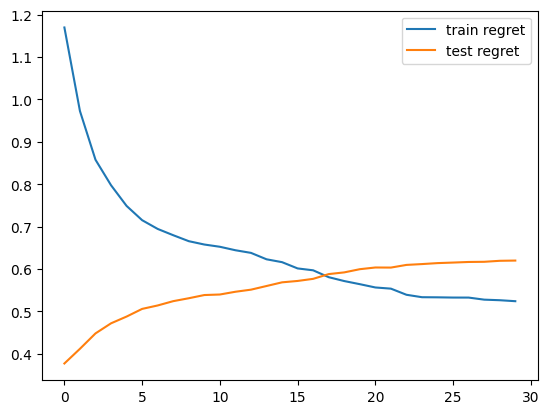

In [107]:
plt.plot(trainregrets, label="train regret")
plt.plot(testregrets, label="test regret")
plt.legend()

In [90]:
pyepo.metric.regret(predmodel, optmodel, testloader)

np.float64(0.05308712010767238)

In [113]:
nuisance_model.linear.bias

Parameter containing:
tensor([ 4.5518,  3.5379,  4.3215,  3.5915,  4.0284,  3.8989,  4.0910,  3.6501,
         3.2139,  4.4000,  3.6726,  3.8691,  4.0967,  0.5680,  4.2449,  3.9729,
         4.2392,  3.9050, -0.1369,  3.4587,  4.1351,  3.8050, -0.0085,  3.9108,
         4.0050,  3.8551,  3.9242, -0.4500,  3.6441,  3.8230,  4.0135,  0.4791,
         3.3211,  3.3549,  3.6060,  3.8743, -0.3453,  3.4877,  4.3278,  4.2546],
       requires_grad=True)